In [51]:
#@title SETUP

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm


In [52]:
#@title 1. CONFIG & DEVICE

# ======
# Device
# ======
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Using device: cpu


In [53]:
#@title 2. HELPERS

def logistic_loglik_mean(x, y_pm1, theta, beta):
    """
    Return mean of log σ(beta * y * <theta,x>).
    x: (n,d), y_pm1: (n,1) in {-1,+1}, theta: (d,)
    """
    z = beta * (x @ theta).unsqueeze(1) * y_pm1
    return torch.mean(torch.log(torch.sigmoid(z) + 1e-12))

@torch.no_grad()
def clip_rows_to_unit_ball(X, radius=1.0):
    """
    Approximate bounded-features assumption by clipping row norms - required by the theorem.
    """
    norms = torch.norm(X, dim=1, keepdim=True) + 1e-12
    scale = torch.clamp(radius / norms, max=1.0)
    return X * scale

def summarize(df):
    g = df.groupby(["beta", "n"], as_index=False)
    out = g.agg(
        subopt_mean=("SubOpt_Q", "mean"),
        subopt_std=("SubOpt_Q", "std"),
        shift_mean=("shift_proxy", "mean"),
        est_mean=("est_proxy", "mean"),
        rhs_mean=("rhs_proxy", "mean"),
        kappa_mean=("kappa", "mean"),
    )
    nrep = df.groupby(["beta", "n"]).size().reset_index(name="reps")
    out = out.merge(nrep, on=["beta", "n"])
    out["subopt_se"] = out["subopt_std"] / np.sqrt(out["reps"])
    return out

# Plotting
def plot_vs_n(summ, beta, out_path="bound_linear_beta_05_main.pdf"):
    # Filter data
    sub = summ[summ["beta"] == beta].sort_values("n")
    n = sub["n"].values

    # Create figure with your larger dimensions
    fig, ax = plt.subplots(figsize=(5, 4))

    # 1. Empirical Suboptimality (Red, Solid, Circles)
    ax.plot(n, sub["subopt_mean"].values,
            linestyle="-", marker="o", linewidth=2.0, markersize=8,
            color='#C62828', label="Empirical SubOpt", alpha=0.9)

    # Add Error Band for Empirical
    ax.fill_between(n,
                    sub["subopt_mean"] - sub["subopt_std"],
                    sub["subopt_mean"] + sub["subopt_std"],
                    color='#C62828', alpha=0.15)

    # 2. Total Upper Bound (Black, Solid, Squares)
    ax.plot(n, sub["rhs_mean"].values,
            linestyle=":", marker="s", linewidth=2.0, markersize=8,
            color='black', label="Theory Upper Bound", alpha=0.8)

    # 3. Component: Shift Error (Green, Dashed)
    ax.plot(n, sub["shift_mean"].values,
            linestyle="--", linewidth=2.0,
            color='#2E7D32', label="Shift Error (Estimate)", alpha=0.9)

    # 4. Component: Estimation Error (Blue, Dashed)
    ax.plot(n, sub["est_mean"].values,
            linestyle="--", linewidth=2.0,
            color='#1565C0', label="Est. Error (Estimate)", alpha=0.9)

    # --- AXIS & STYLING ---
    ax.set_yscale("log")
    # ax.set_xscale("log") # Optional: Uncomment if n spans orders of magnitude

    ax.set_xlabel("Number of Training Samples", fontsize=20)
    ax.set_ylabel("Deployment Error", fontsize=20)
    # ax.set_title(f"Theorem 5.1 Illustration ($\\beta={beta}$)", fontsize=13, pad=12)

    # Larger Ticks
    ax.tick_params(axis='both', which='major', labelsize=20)

    # Grid & Legend
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(frameon=True, loc="best", fontsize=16)

    plt.tight_layout()

    # Save if path provided
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {out_path}")

    plt.show()

In [54]:
#@title 3. SOLVERS

def solve_pairwise_mle_lbfgs(X, y_pm1, beta=1.0, l2=1e-4, max_iter=300):
    """
    Minimize negative mean log σ(beta y <θ,x>) + 0.5*l2||θ||^2 - regularizer added from theory
    """
    n, d = X.shape
    theta = torch.zeros(d, device=X.device, requires_grad=True)

    opt = optim.LBFGS(
        [theta],
        lr=1.0,
        max_iter=max_iter,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
        history_size=100,
        line_search_fn="strong_wolfe",
    )

    def closure():
        opt.zero_grad()
        # negative log-likelihood
        ll = logistic_loglik_mean(X, y_pm1, theta, beta)
        loss = -ll + 0.5 * l2 * torch.sum(theta**2)
        loss.backward()
        return loss

    opt.step(closure)
    return theta.detach()

In [55]:
#@title 4. DATA GENERATION

# =======================
# Data generation: P vs Q
# =======================
@torch.no_grad()
def sample_PQ(n, d_c=5, d_s=5, shift_s=0.5, corr=0.6, lam_c=1.0, lam_s=1.0,
             which="P", clip_radius=1.0):
    """
    Generate (x, y) with x split into causal/spurious blocks, Gaussian with controllable shift/corr.

    x_c ~ N(0, lam_c I)
    x_s = corr * A x_c + sqrt(1-corr^2)*eps + mean_shift
    where mean_shift differs between P and Q to induce distribution shift.

    Labels follow a fixed teacher:
      y ~ Bernoulli(sigmoid(<theta*, x>))
    returned as y_pm1 in {-1,+1}.
    """
    d = d_c + d_s
    x_c = torch.randn(n, d_c, device=DEVICE) * math.sqrt(lam_c)

    # map causal into spurious dims
    A = torch.randn(d_s, d_c, device=DEVICE) / math.sqrt(d_c)
    eps = torch.randn(n, d_s, device=DEVICE) * math.sqrt(lam_s)

    mean_shift = torch.zeros(d_s, device=DEVICE)
    if which == "Q":
        mean_shift += shift_s  # spurious mean shift at deployment

    x_s = (corr * (x_c @ A.T) + math.sqrt(max(1.0 - corr**2, 0.0)) * eps) + mean_shift
    X = torch.cat([x_c, x_s], dim=1)

    # bounded features proxy
    X = clip_rows_to_unit_ball(X, radius=clip_radius)

    # fixed teacher (nonzero or zero spurious are possible)
    # keep it fixed across calls by using global tensors set once outside
    return X


@torch.no_grad()
def sample_labels_from_teacher(X, theta_star):
    """
    y ~ Bernoulli(sigmoid(<theta*, X>)), then map to {-1,+1}.
    """
    p = torch.sigmoid((X @ theta_star)).unsqueeze(1)
    y01 = (torch.rand(X.shape[0], 1, device=DEVICE) < p).float()
    y_pm1 = 2.0 * y01 - 1.0
    return y_pm1

In [56]:
#@title 5. THEOREM QUANTITIES

# ============================================================
# Theorem quantities: H_P, Σbar(Q), κΠ, shift proxy, Γ_n proxy
# ============================================================
@torch.no_grad()
def fisher_like_matrix(X, theta, beta, l2=0.0):
    """
    H ≈ E[ 4 σ(z)(1-σ(z)) x x^T ] + l2 I
    where z = beta <theta, x>.
    """
    n, d = X.shape
    z = beta * (X @ theta)  # (n,)
    w = 4.0 * torch.sigmoid(z) * (1.0 - torch.sigmoid(z))  # (n,)
    # weighted covariance
    Xw = X * w.unsqueeze(1)  # (n,d)
    H = (X.T @ Xw) / n
    if l2 > 0:
        H = H + l2 * torch.eye(d, device=X.device, dtype=X.dtype)
    return H

@torch.no_grad()
def kappa_generalized(Sigma_bar_Q, H_P, eps=1e-8):
    """
    κΠ ≈ λ_max of generalized eigenproblem:
      Sigma_bar_Q v = κ H_P v
    computed via eig of H^{-1/2} Σ H^{-1/2}.
    """
    d = H_P.shape[0]
    # stabilize
    Hs = H_P + eps * torch.eye(d, device=H_P.device)
    # eigendecomp for H^{-1/2}
    evals, evecs = torch.linalg.eigh(Hs)
    inv_sqrt = evecs @ torch.diag(torch.clamp(evals, min=eps).rsqrt()) @ evecs.T
    M = inv_sqrt @ Sigma_bar_Q @ inv_sqrt
    lam_max = torch.linalg.eigvalsh((M + M.T) / 2.0).max().item()
    return float(lam_max)

@torch.no_grad()
def shift_proxy_mu(PX, QX, theta_hat, beta):
    """
    Use Proposition 5.2 first-order margin proxy:
      m_D(θ)=E[β θ^T x] = β θ^T μ(D)
    shift proxy = |m_Q(θ_hat)-m_P(θ_hat)|
    """
    muP = PX.mean(dim=0)
    muQ = QX.mean(dim=0)
    mP = beta * torch.dot(theta_hat, muP).item()
    mQ = beta * torch.dot(theta_hat, muQ).item()
    return abs(mQ - mP), mP, mQ, float(torch.norm(muP).item()), float(torch.norm(muQ).item())


def gamma_n_proxy(beta, d, n, delta=0.05, B=5.0, l2=0.0):
    """
    Proxy for Γ_n in theorem statement:
      Γ_n = 2β * sqrt((d + log(1/δ))/n) + B * λ
    (matches the structure shown in the PDF snippet; use as a proxy)
    """
    return 2.0 * beta * math.sqrt((d + math.log(1.0 / delta)) / max(n, 1)) + B * l2

In [57]:
#@title 6. EXPERIMENT

def run_theorem5p1_validation(
    betas=(0.1, 0.2, 0.5, 1.0),
    n_grid=(500, 1000, 2000, 4000, 8000),
    seeds=20,
    d_c=5,
    d_s=5,
    l2=0.0,
    clip_radius=1.0,
    shift_s=0.5,
    corr=0.6,
    nQ_star=200000,  # large to approximate θ*_Q
):
    d = d_c + d_s

    # fix teacher once
    set_seed(123)
    theta_star = torch.randn(d, device=DEVICE)
    theta_star[d_c:] *= 0.0  # spurious can be zero (level (ii)) or nonzero (say 1.0 - level (iii))

    rows = []

    for beta in betas:
        # approximate θ*_Q once per beta using big Q sample
        set_seed(999 + int(1000 * beta))
        XQ_big = sample_PQ(nQ_star, d_c, d_s, shift_s, corr, which="Q", clip_radius=clip_radius)
        yQ_big = sample_labels_from_teacher(XQ_big, theta_star)
        theta_Q_star = solve_pairwise_mle_lbfgs(XQ_big, yQ_big, beta=beta, l2=l2, max_iter=400)

        JQ_star = float(logistic_loglik_mean(XQ_big[:50000], yQ_big[:50000], theta_Q_star, beta).item())

        for n in n_grid:
            for seed in tqdm(range(seeds), leave=False, desc=f"beta={beta}, n={n}"):
                set_seed(seed + 10_000 * int(100 * beta) + 1_000_000 * (n // 500))

                # train sample from P
                XP = sample_PQ(n, d_c, d_s, shift_s, corr, which="P", clip_radius=clip_radius)
                yP = sample_labels_from_teacher(XP, theta_star)

                # fit theta_hat on P
                theta_hat = solve_pairwise_mle_lbfgs(XP, yP, beta=beta, l2=l2, max_iter=300)

                # evaluate suboptimality on Q (fresh Q sample)
                XQ_eval = sample_PQ(50000, d_c, d_s, shift_s, corr, which="Q", clip_radius=clip_radius)
                yQ_eval = sample_labels_from_teacher(XQ_eval, theta_star)

                JQ_hat = float(logistic_loglik_mean(XQ_eval, yQ_eval, theta_hat, beta).item())
                subopt = JQ_star - JQ_hat

                # compute shift proxy (need moments from P and Q; reuse samples)
                shift_val, mP, mQ, muP_norm, muQ_norm = shift_proxy_mu(XP, XQ_eval[:n], theta_hat, beta)

                # compute κΠ using H_P at theta_train and Σbar(Q) at theta_train
                H_P = fisher_like_matrix(XP, theta_hat, beta, l2=l2)
                Sigma_bar_Q = fisher_like_matrix(XQ_eval, theta_hat, beta, l2=0.0)  # barSigma(Q) has no ridge in statement snippet
                kappa = kappa_generalized(Sigma_bar_Q, H_P)

                # estimation proxy
                Gamma = gamma_n_proxy(beta=beta, d=d, n=n, delta=0.05, B=5.0, l2=l2)
                est_proxy = (kappa / n) * (Gamma ** 2)

                rows.append({
                    "beta": beta,
                    "n": n,
                    "seed": seed,
                    "SubOpt_Q": subopt,
                    "JQ_star": JQ_star,
                    "JQ_hat": JQ_hat,
                    "shift_proxy": shift_val,
                    "mP": mP,
                    "mQ": mQ,
                    "muP_norm": muP_norm,
                    "muQ_norm": muQ_norm,
                    "kappa": kappa,
                    "Gamma": Gamma,
                    "est_proxy": est_proxy,
                    "rhs_proxy": shift_val + est_proxy,
                })

    return pd.DataFrame(rows)

beta=0.5, n=500:   0%|          | 0/20 [00:00<?, ?it/s]

beta=0.5, n=1000:   0%|          | 0/20 [00:00<?, ?it/s]

beta=0.5, n=2000:   0%|          | 0/20 [00:00<?, ?it/s]

beta=0.5, n=4000:   0%|          | 0/20 [00:00<?, ?it/s]

beta=0.5, n=8000:   0%|          | 0/20 [00:00<?, ?it/s]

   beta     n  subopt_mean  subopt_std  shift_mean      est_mean  rhs_mean  \
0   0.5   500     0.017534    0.008181    0.101245  2.122030e-04  0.101458   
1   0.5  1000     0.007084    0.003087    0.069333  5.070371e-05  0.069383   
2   0.5  2000     0.003563    0.001600    0.049869  1.213468e-05  0.049881   
3   0.5  4000     0.002530    0.000895    0.030428  3.100361e-06  0.030431   
4   0.5  8000     0.001524    0.001201    0.020291  7.282035e-07  0.020292   

   kappa_mean  reps  subopt_se  
0    4.082167    20   0.001829  
1    3.901566    20   0.000690  
2    3.734972    20   0.000358  
3    3.817082    20   0.000200  
4    3.586179    20   0.000268  
Saved figure to: bound_linear_beta_05_main.pdf


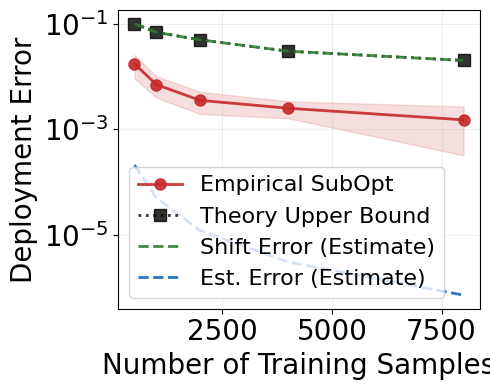

In [58]:
#@title MAIN

if __name__ == "__main__":
    df = run_theorem5p1_validation(
        betas=[0.5],
        n_grid=(500, 1000, 2000, 4000, 8000),
        seeds=20,
        d_c=5,
        d_s=5,
        l2=0.0,
        clip_radius=1.0,
        shift_s=0.5,
        corr=0.6,
        nQ_star=2000000,
    )

    summ = summarize(df)
    print(summ.head(12))

    # Plot per beta
    for b in sorted(summ["beta"].unique()):
        plot_vs_n(summ, beta=b)